In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets,transforms,models
from torch.utils.data import Dataset,DataLoader,random_split,Subset,WeightedRandomSampler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import shutil
from PIL import Image,ImageFile
import kagglehub
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [2]:
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [3]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
path = kagglehub.dataset_download("tschandl/isic2018-challenge-task1-data-segmentation")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/isic2018-challenge-task1-data-segmentation


In [5]:
print(os.listdir(path))
print(os.listdir(os.path.join(path,"ISIC2018_Task1-2_Training_Input"))[0:10])
print(os.listdir(os.path.join(path,"ISIC2018_Task1_Training_GroundTruth"))[0:10])

['ISIC2018_Task1-2_Training_Input', 'ISIC2018_Task1_Training_GroundTruth', 'ISIC2018_Task1-2_Test_Input', 'ISIC2018_Task1-2_Validation_Input']
['ISIC_0012706.jpg', 'ISIC_0010192.jpg', 'ISIC_0010017.jpg', 'ISIC_0013000.jpg', 'ISIC_0013166.jpg', 'ISIC_0003308.jpg', 'ISIC_0012332.jpg', 'ISIC_0014291.jpg', 'ISIC_0014729.jpg', 'ISIC_0000012.jpg']
['ISIC_0000505_segmentation.png', 'ISIC_0015129_segmentation.png', 'ISIC_0014743_segmentation.png', 'ISIC_0000057_segmentation.png', 'ISIC_0015211_segmentation.png', 'ISIC_0012880_segmentation.png', 'ISIC_0005555_segmentation.png', 'ISIC_0012379_segmentation.png', 'ISIC_0000226_segmentation.png', 'ISIC_0014233_segmentation.png']


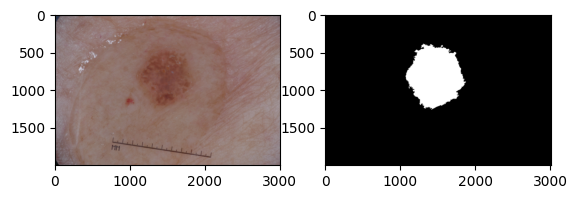

In [6]:
plt.subplot(1,2,1)
plt.imshow(plt.imread(os.path.join(path,"ISIC2018_Task1-2_Training_Input","ISIC_0012880.jpg")))
plt.subplot(1,2,2)
plt.imshow(plt.imread(os.path.join(path,"ISIC2018_Task1_Training_GroundTruth","ISIC_0012880_segmentation.png")),cmap='gray')
plt.show()

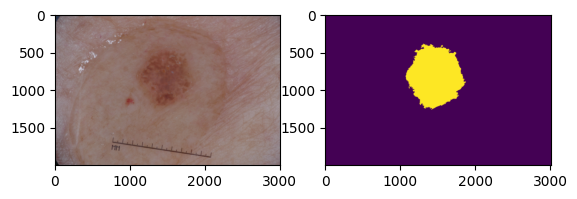

In [7]:
plt.subplot(1,2,1)
plt.imshow(plt.imread(os.path.join(path,"ISIC2018_Task1-2_Training_Input","ISIC_0012880.jpg")))
plt.subplot(1,2,2)
plt.imshow(plt.imread(os.path.join(path,"ISIC2018_Task1_Training_GroundTruth","ISIC_0012880_segmentation.png")),cmap='viridis')
plt.show()

In [8]:
print(len(os.listdir(os.path.join(path,"ISIC2018_Task1-2_Training_Input"))))
print(len(os.listdir(os.path.join(path,"ISIC2018_Task1_Training_GroundTruth"))))

2596
2596


In [9]:
class ISIC_Dataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.images = [f for f in os.listdir(image_dir) if f.lower().endswith((".jpg", ".png", ".jpeg"))]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        img_path = os.path.join(self.image_dir, self.images[index])
        mask_path = os.path.join(self.mask_dir, self.images[index].replace(".jpg", "_segmentation.png"))
        image = np.array(Image.open(img_path).convert("RGB"))
        mask = np.array(Image.open(mask_path).convert("L"), dtype=np.float64)
        mask[mask == 255.0] = 1.0
        if self.transform is not None:
            augmentations = self.transform(image=image, mask=mask)
            image = augmentations["image"]
            mask = augmentations["mask"]
        mask=np.expand_dims(mask,0)
        return image, mask

In [114]:
train_img_dir=os.path.join(path,"ISIC2018_Task1-2_Training_Input")
train_mask_dir=os.path.join(path,"ISIC2018_Task1_Training_GroundTruth")
input_img_size=256
batch_size=16
train_transform = A.Compose([
            A.Resize(height=input_img_size, width=input_img_size),
            A.Normalize(
                mean=[0.0, 0.0, 0.0],
                std=[1.0, 1.0, 1.0],
                max_pixel_value=255.0,
            ),
             ToTensorV2()]
)

test_transform=A.Compose([
            A.Resize(height=input_img_size, width=input_img_size),
            A.Normalize(
                mean=[0.0, 0.0, 0.0],
                std=[1.0, 1.0, 1.0],
                max_pixel_value=255.0,
            ),
             ToTensorV2()]
)
dataset=ISIC_Dataset(train_img_dir, train_mask_dir, transform=train_transform)

total_size=len(dataset)
train_size=int(0.8*total_size)
test_size=total_size-train_size

train_dataset,test_dataset=random_split(dataset,[train_size,test_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

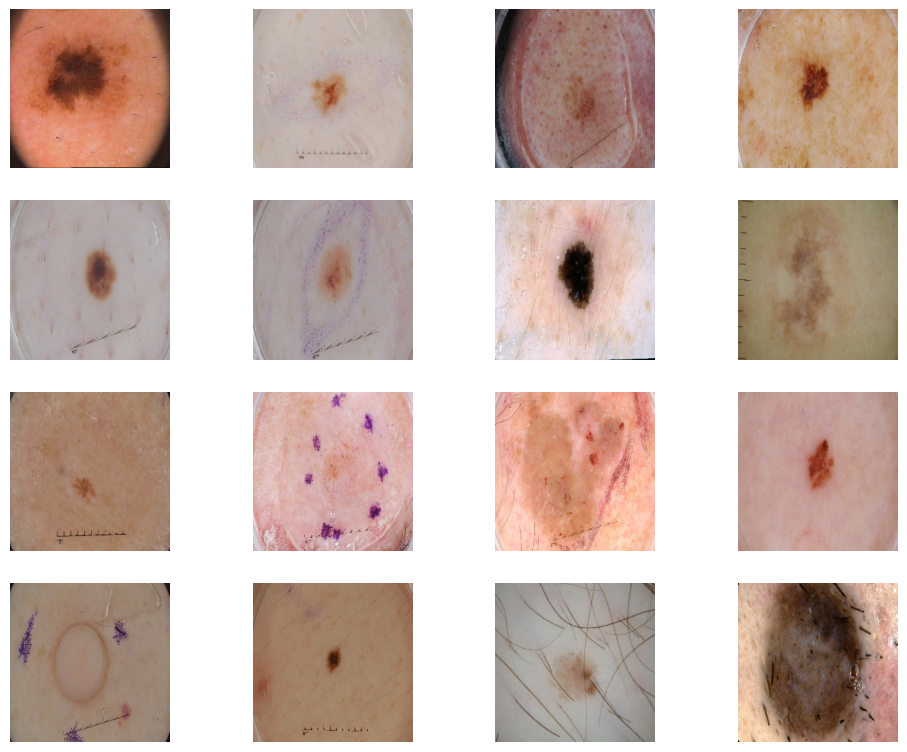

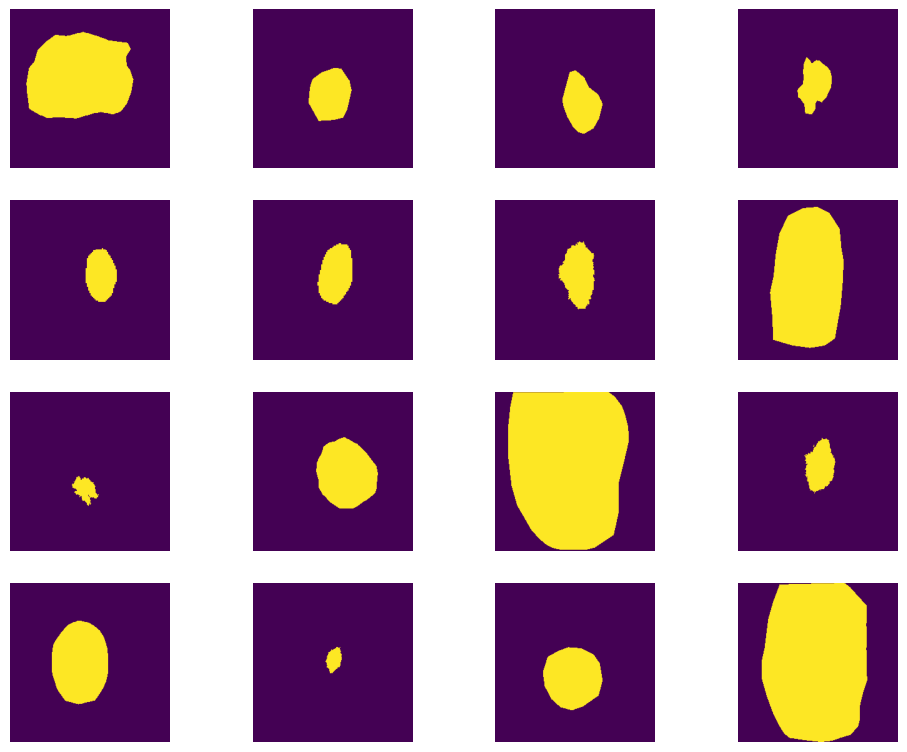

In [14]:
def visualize(visualizer_loader,n=5):
    x, y = next(iter(visualizer_loader))
    x, y = x.to(device), y.to(device)
    plt.figure(figsize=(12,12))
    for i in range(n):
        plt.subplot(n//4+1, 4, i+1)
        plt.imshow(x[i].cpu().squeeze().permute(1,2,0))
        plt.axis('off')
    plt.show()
    plt.figure(figsize=(12,12))
    for i in range(n):
        plt.subplot(n//4+1, 4, i+1)
        plt.imshow(y[i].cpu().squeeze())
        plt.axis('off')
    plt.show()
visualize(test_loader,16)

In [101]:
def dice_coeff_batch(pred, target, smooth=1):
    pred = pred.view(pred.size(0), -1) 
    target = target.view(target.size(0), -1) 
    intersection = (pred * target).sum(dim=1) 
    total = pred.sum(dim=1) + target.sum(dim=1)
    dice_per_sample = (2. * intersection + smooth) / (total + smooth)
    return dice_per_sample.sum() 

def iou_coeff_batch(y_true, y_pred, eps=1e-7):
    intersection = (y_true * y_pred).sum(dim=(1,2,3))
    union = y_true.sum(dim=(1,2,3)) + y_pred.sum(dim=(1,2,3)) - intersection
    iou = (intersection + eps) / (union + eps)
    return iou.sum().item()   


def iou_score(preds, targets, eps=1e-7):
    preds = preds.float()
    targets = targets.float()
    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum() - intersection
    iou = (intersection + eps) / (union + eps)
    return iou.item()
def stat_model(model, test_loader, loss_fn):
    model.eval()
    total_loss = 0.0
    total = 0

    dice_total = 0.0
    iou_total = 0.0
    batches = 0

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            x=model(x)
            loss = loss_fn(x, y)
            
            total_loss += loss.item() * y.size(0)
            total += y.size(0)
            logits = torch.sigmoid(x)

            preds = (logits > 0.5).float()

            dice_total += dice_coeff_batch(preds, y)
            iou_total += iou_coeff_batch(preds, y)
            batches += 1

    avg_loss = total_loss / total
    avg_dice = dice_total / total
    avg_iou = iou_total / total

    print(f"Loss: {avg_loss:.4f} | Dice: {avg_dice:.4f} | IoU: {avg_iou:.4f}")
    return avg_loss, avg_dice, avg_iou


In [100]:
def train_model(model,train_loader,test_loader,optimizer,loss_fn,train_loss,test_loss,epochs=5):
  for epoch in range(epochs):
    model.train()
    total_loss=0
    total=0
    step=0
    for x,y in train_loader:
      total+=y.size(0)
      step+=1
      x,y=x.to(device),y.to(device)
      optimizer.zero_grad()
      x=model(x)
      # x=torch.sigmoid(x)
      loss=loss_fn(x,y)
      loss.backward()
      optimizer.step()
      total_loss+=loss.item()*y.size(0)
      if step%20==0:
          print(f"Step {step} : Intermediate Loss = {total_loss/total :.2f}")
    total_loss/=total
    print(f"Epoch {epoch+1}")
    print(f"Loss : {total_loss:.4f}")
    print("Training Loss")
    train_loss.append(total_loss)
    print(f"Loss: {total_loss :.2f}")
    print("Testing Loss")
    test_loss.append(test_model(model,test_loader,loss_fn))
    stat_model(model,test_loader,loss_fn)
    # test_loss.append(test_model(model,train_loader))

def test_model(model,test_loader,loss_fn):
  model.eval()
  total_loss=0
  total=0
  with torch.no_grad():
    for x,y in test_loader:
      x,y=x.to(device),y.to(device)
      x=model(x)
      # x=torch.sigmoid(x)
      loss=loss_fn(x,y)
      total_loss+=loss.item()*y.size(0)
      total+=y.size(0)
  total_loss/=total
  print(f"Loss: {total_loss :.2f}")
  return total_loss

In [94]:
#Model Building
class Residual(nn.Module):
    def __init__(self, fn):
        super().__init__()
        self.fn = fn
    def forward(self, x):
        return nn.functional.relu(self.fn(x) + x)
def conv_block(input_channel,output_channel,residual=False):
    if not residual:
        return nn.Sequential(
            nn.Conv2d(input_channel, output_channel, 3, padding=1),
            nn.BatchNorm2d(output_channel),
            nn.ReLU(),
            nn.Conv2d(output_channel, output_channel, 3, padding=1),
            nn.BatchNorm2d(output_channel),
            nn.ReLU()
        )
    else:
        return nn.Sequential(
            nn.Conv2d(input_channel, output_channel, 3, padding=1),
            nn.BatchNorm2d(output_channel),
            nn.ReLU(),
            nn.Conv2d(output_channel, output_channel, 3, padding=1),
            nn.BatchNorm2d(output_channel)
        )
class UNET(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512],):
        super(UNET, self).__init__()
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
       
        for feature in features:
            self.downs.append(conv_block(in_channels, feature))
            in_channels = feature

        for feature in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2,))
            self.ups.append(conv_block(feature*2, feature))

        self.bottleneck = nn.Conv2d(features[-1], features[-1]*2,3,padding=1)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]
        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx//2]
            if x.shape != skip_connection.shape:
                x = TF.resize(x, size=skip_connection.shape[2:])
            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx+1](concat_skip)
        x=self.final_conv(x)
        return x

In [41]:
model=UNET()
model=model.to(device)
optimizer=optim.Adam(model.parameters(),lr=0.0003,weight_decay=1e-4)
loss_fn=nn.BCEWithLogitsLoss()
train_loss=[]
test_loss=[]
train_model(model,train_loader,test_loader,optimizer,loss_fn,train_loss,test_loss,12)
test_model(model,test_loader,loss_fn)

Step 20 : Intermediate Loss = 0.47
Step 40 : Intermediate Loss = 0.44
Step 60 : Intermediate Loss = 0.41
Step 80 : Intermediate Loss = 0.40
Step 100 : Intermediate Loss = 0.38
Step 120 : Intermediate Loss = 0.38
Epoch 1
Loss : 0.3684
Training Loss
Loss: 0.37
Testing Loss
Loss: 0.29
Step 20 : Intermediate Loss = 0.29
Step 40 : Intermediate Loss = 0.28
Step 60 : Intermediate Loss = 0.28
Step 80 : Intermediate Loss = 0.28
Step 100 : Intermediate Loss = 0.28
Step 120 : Intermediate Loss = 0.28
Epoch 2
Loss : 0.2787
Training Loss
Loss: 0.28
Testing Loss
Loss: 0.25
Step 20 : Intermediate Loss = 0.24
Step 40 : Intermediate Loss = 0.24
Step 60 : Intermediate Loss = 0.25
Step 80 : Intermediate Loss = 0.25
Step 100 : Intermediate Loss = 0.25
Step 120 : Intermediate Loss = 0.25
Epoch 3
Loss : 0.2499
Training Loss
Loss: 0.25
Testing Loss
Loss: 0.23
Step 20 : Intermediate Loss = 0.23
Step 40 : Intermediate Loss = 0.23
Step 60 : Intermediate Loss = 0.23
Step 80 : Intermediate Loss = 0.23
Step 100 : 

KeyboardInterrupt: 

In [43]:
model1=model
train_loss_1=train_loss
test_loss_1=test_loss

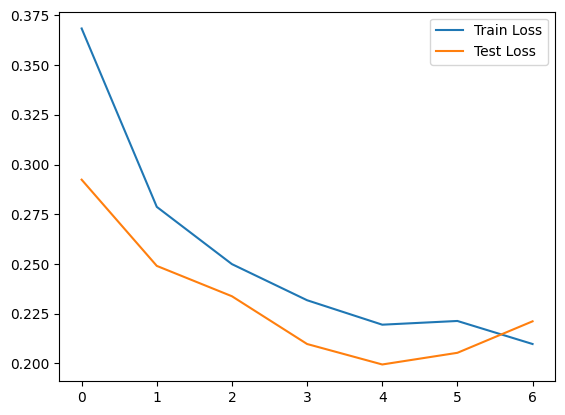

In [46]:
plt.plot(train_loss_1,label="Train Loss")
plt.plot(test_loss_1,label="Test Loss")
plt.legend()
plt.show()

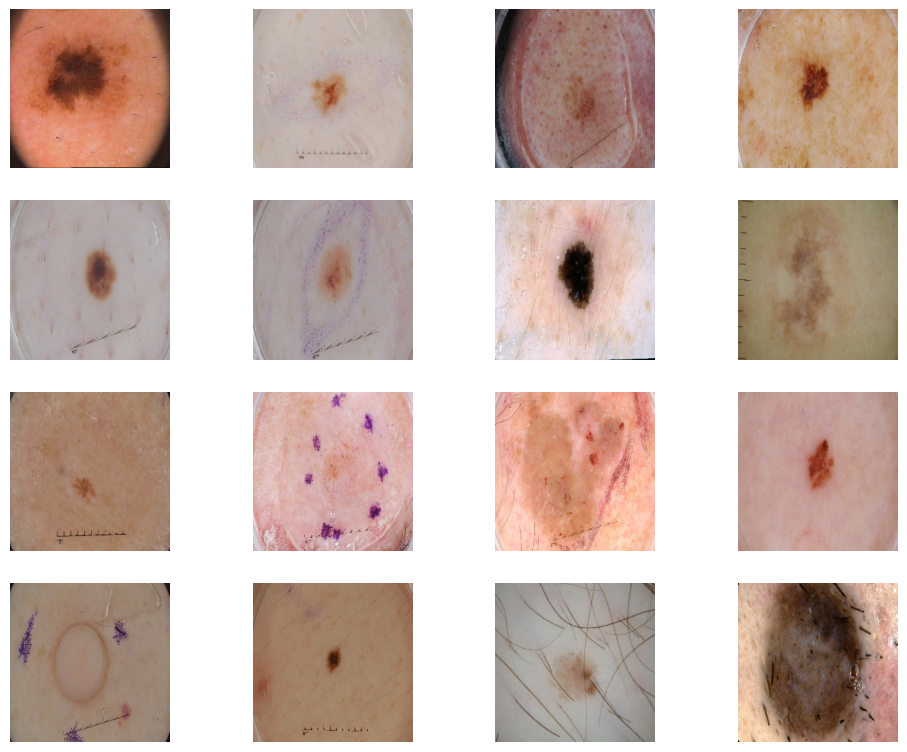

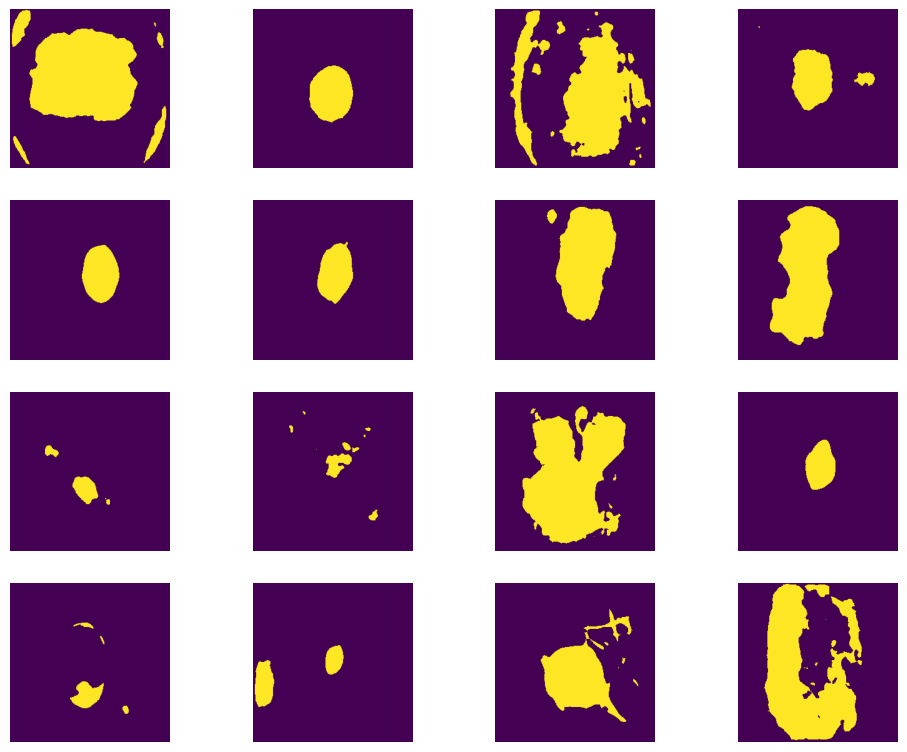

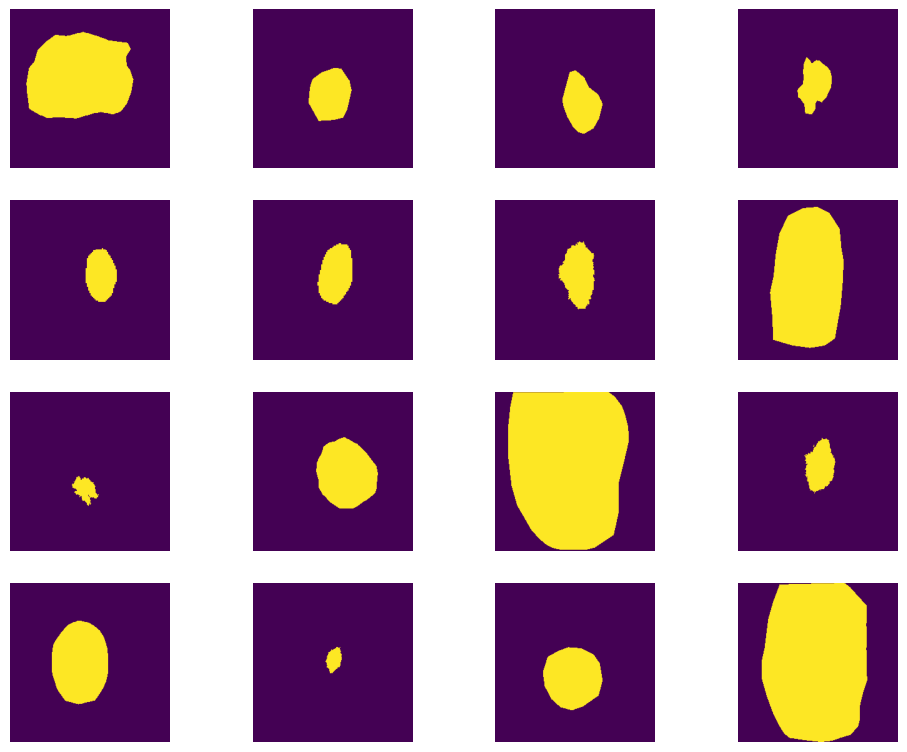

In [48]:
def visualize_model(model,visualizer_loader,n=5):
    x, y = next(iter(visualizer_loader))
    x, y = x.to(device), y.to(device)
    plt.figure(figsize=(12,12))
    for i in range(n):
        plt.subplot(n//4+1, 4, i+1)
        plt.imshow(x[i].cpu().squeeze().permute(1,2,0))
        plt.axis('off')
    plt.show()
    preds = model(x)
    preds = torch.sigmoid(preds)          # convert logits → probability
    preds = (preds > 0.5).float()          # binarize
    plt.figure(figsize=(12,12))
    for i in range(n):
        plt.subplot(n//4+1, 4, i+1)
        plt.imshow(preds[i].cpu().squeeze())
        plt.axis('off')
    plt.show()
    plt.figure(figsize=(12,12))
    for i in range(n):
        plt.subplot(n//4+1, 4, i+1)
        plt.imshow(y[i].cpu().squeeze())
        plt.axis('off')
    plt.show()
visualize_model(model1,test_loader,16)

In [67]:
loss_fn=nn.BCEWithLogitsLoss()
stat_model(model1,test_loader,loss_fn)

Loss: 0.6607 | Dice: 0.7936 | IoU: 0.6616


(0.6606773457191731, 0.7936309377352396, 0.6616246600945791)

In [95]:
model=UNET()
model=model.to(device)
optimizer=optim.Adam(model.parameters(),lr=0.0003,weight_decay=1e-4)
loss_fn=nn.BCEWithLogitsLoss()
train_loss=[]
test_loss=[]
train_model(model,train_loader,test_loader,optimizer,loss_fn,train_loss,test_loss,10)

Step 20 : Intermediate Loss = 0.79
Step 40 : Intermediate Loss = 0.77
Step 60 : Intermediate Loss = 0.76
Step 80 : Intermediate Loss = 0.75
Step 100 : Intermediate Loss = 0.74
Step 120 : Intermediate Loss = 0.74
Epoch 1
Loss : 0.7326
Training Loss
Loss: 0.73
Testing Loss
Loss: 0.70
Loss: 0.6968 | Dice: 0.6773 | IoU: 0.5795
Step 20 : Intermediate Loss = 0.69
Step 40 : Intermediate Loss = 0.70
Step 60 : Intermediate Loss = 0.69
Step 80 : Intermediate Loss = 0.69
Step 100 : Intermediate Loss = 0.69
Step 120 : Intermediate Loss = 0.69
Epoch 2
Loss : 0.6856
Training Loss
Loss: 0.69
Testing Loss
Loss: 0.67
Loss: 0.6682 | Dice: 0.7130 | IoU: 0.6180
Step 20 : Intermediate Loss = 0.67
Step 40 : Intermediate Loss = 0.67
Step 60 : Intermediate Loss = 0.67
Step 80 : Intermediate Loss = 0.67
Step 100 : Intermediate Loss = 0.67
Step 120 : Intermediate Loss = 0.67
Epoch 3
Loss : 0.6693
Training Loss
Loss: 0.67
Testing Loss
Loss: 0.67
Loss: 0.6685 | Dice: 0.7307 | IoU: 0.6284
Step 20 : Intermediate Lo

KeyboardInterrupt: 

In [96]:
torch.save(model.state_dict(), "model.pth")
torch.save(model1.state_dict(), "model1.pth")

In [102]:
optimizer=optim.Adam(model.parameters(),lr=0.0003,weight_decay=1e-4)
loss_fn=nn.BCEWithLogitsLoss()
train_loss=[]
test_loss=[]
train_model(model1,train_loader,test_loader,optimizer,loss_fn,train_loss,test_loss,5)

Step 20 : Intermediate Loss = 0.19
Step 40 : Intermediate Loss = 0.20
Step 60 : Intermediate Loss = 0.20
Step 80 : Intermediate Loss = 0.21
Step 100 : Intermediate Loss = 0.21
Step 120 : Intermediate Loss = 0.21
Epoch 1
Loss : 0.2100
Training Loss
Loss: 0.21
Testing Loss
Loss: 0.20
Loss: 0.1986 | Dice: 0.7516 | IoU: 0.6561
Step 20 : Intermediate Loss = 0.23
Step 40 : Intermediate Loss = 0.22
Step 60 : Intermediate Loss = 0.22
Step 80 : Intermediate Loss = 0.22
Step 100 : Intermediate Loss = 0.22
Step 120 : Intermediate Loss = 0.21
Epoch 2
Loss : 0.2113
Training Loss
Loss: 0.21
Testing Loss
Loss: 0.20
Loss: 0.1986 | Dice: 0.7452 | IoU: 0.6504
Step 20 : Intermediate Loss = 0.22
Step 40 : Intermediate Loss = 0.22
Step 60 : Intermediate Loss = 0.21
Step 80 : Intermediate Loss = 0.21
Step 100 : Intermediate Loss = 0.21
Step 120 : Intermediate Loss = 0.21
Epoch 3
Loss : 0.2108
Training Loss
Loss: 0.21
Testing Loss
Loss: 0.20
Loss: 0.1997 | Dice: 0.7425 | IoU: 0.6483
Step 20 : Intermediate Lo

In [103]:
model=UNET(in_channels=3, out_channels=1, features=[64, 128, 256])
model=model.to(device)
optimizer=optim.Adam(model.parameters(),lr=0.0003,weight_decay=1e-4)
loss_fn=nn.BCEWithLogitsLoss()
train_loss=[]
test_loss=[]
train_model(model,train_loader,test_loader,optimizer,loss_fn,train_loss,test_loss,10)

Step 20 : Intermediate Loss = 0.52
Step 40 : Intermediate Loss = 0.46
Step 60 : Intermediate Loss = 0.43
Step 80 : Intermediate Loss = 0.42
Step 100 : Intermediate Loss = 0.41
Step 120 : Intermediate Loss = 0.40
Epoch 1
Loss : 0.3929
Training Loss
Loss: 0.39
Testing Loss
Loss: 0.34
Loss: 0.3405 | Dice: 0.6759 | IoU: 0.5641
Step 20 : Intermediate Loss = 0.31
Step 40 : Intermediate Loss = 0.32
Step 60 : Intermediate Loss = 0.31
Step 80 : Intermediate Loss = 0.32
Step 100 : Intermediate Loss = 0.32
Step 120 : Intermediate Loss = 0.32
Epoch 2
Loss : 0.3194
Training Loss
Loss: 0.32
Testing Loss
Loss: 0.40
Loss: 0.4008 | Dice: 0.5912 | IoU: 0.4668
Step 20 : Intermediate Loss = 0.30
Step 40 : Intermediate Loss = 0.30
Step 60 : Intermediate Loss = 0.29
Step 80 : Intermediate Loss = 0.29
Step 100 : Intermediate Loss = 0.29
Step 120 : Intermediate Loss = 0.29
Epoch 3
Loss : 0.2860
Training Loss
Loss: 0.29
Testing Loss
Loss: 0.28
Loss: 0.2806 | Dice: 0.7123 | IoU: 0.6060
Step 20 : Intermediate Lo

In [104]:
torch.save(model.state_dict(), "model2.pth")

In [105]:
model3=model

In [106]:
#Model Building
class Residual(nn.Module):
    def __init__(self, fn,input_channel,output_channel):
        super().__init__()
        self.fn = fn
        if input_channel!=output_channel:
            self.F=nn.Conv2d(input_channel,output_channel,kernel_size=1,bias=False)
        else:
            self.F=nn.Identity()
    def forward(self, x):
        y=self.F(x)
        return nn.functional.relu(self.fn(x) + y)
def conv_block(input_channel,output_channel,residual=False):
    if not residual:
        return nn.Sequential(
            nn.Conv2d(input_channel, output_channel, 3, padding=1),
            nn.BatchNorm2d(output_channel),
            nn.ReLU(),
            nn.Conv2d(output_channel, output_channel, 3, padding=1),
            nn.BatchNorm2d(output_channel),
            nn.ReLU()
        )
    else:
        return Residual(nn.Sequential(
            nn.Conv2d(input_channel, output_channel, 3, padding=1),
            nn.BatchNorm2d(output_channel),
            nn.ReLU(),
            nn.Conv2d(output_channel, output_channel, 3, padding=1),
            nn.BatchNorm2d(output_channel)
        ),input_channel,output_channel)
class Residual_UNET(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512],):
        super(Residual_UNET, self).__init__()
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
       
        for feature in features:
            self.downs.append(conv_block(in_channels, feature,residual=True))
            in_channels = feature

        for feature in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2,))
            self.ups.append(conv_block(feature*2, feature,residual=True))

        self.bottleneck = nn.Conv2d(features[-1], features[-1]*2,3,padding=1)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]
        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx//2]
            if x.shape != skip_connection.shape:
                x = TF.resize(x, size=skip_connection.shape[2:])
            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx+1](concat_skip)
        x=self.final_conv(x)
        return x
model=Residual_UNET(in_channels=3, out_channels=1, features=[64, 128, 256])
model=model.to(device)
optimizer=optim.Adam(model.parameters(),lr=0.0003,weight_decay=1e-4)
loss_fn=nn.BCEWithLogitsLoss()
train_loss=[]
test_loss=[]
train_model(model,train_loader,test_loader,optimizer,loss_fn,train_loss,test_loss,8)

Step 20 : Intermediate Loss = 0.52
Step 40 : Intermediate Loss = 0.44
Step 60 : Intermediate Loss = 0.40
Step 80 : Intermediate Loss = 0.38
Step 100 : Intermediate Loss = 0.36
Step 120 : Intermediate Loss = 0.36
Epoch 1
Loss : 0.3566
Training Loss
Loss: 0.36
Testing Loss
Loss: 0.33
Loss: 0.3287 | Dice: 0.5253 | IoU: 0.4214
Step 20 : Intermediate Loss = 0.29
Step 40 : Intermediate Loss = 0.29
Step 60 : Intermediate Loss = 0.29
Step 80 : Intermediate Loss = 0.29
Step 100 : Intermediate Loss = 0.29
Step 120 : Intermediate Loss = 0.28
Epoch 2
Loss : 0.2837
Training Loss
Loss: 0.28
Testing Loss
Loss: 0.26
Loss: 0.2613 | Dice: 0.6974 | IoU: 0.5987
Step 20 : Intermediate Loss = 0.26
Step 40 : Intermediate Loss = 0.26
Step 60 : Intermediate Loss = 0.25
Step 80 : Intermediate Loss = 0.26
Step 100 : Intermediate Loss = 0.26
Step 120 : Intermediate Loss = 0.26
Epoch 3
Loss : 0.2560
Training Loss
Loss: 0.26
Testing Loss
Loss: 0.25
Loss: 0.2506 | Dice: 0.6842 | IoU: 0.5896
Step 20 : Intermediate Lo

In [107]:
torch.save(model.state_dict(), "model3.pth")
model4=model

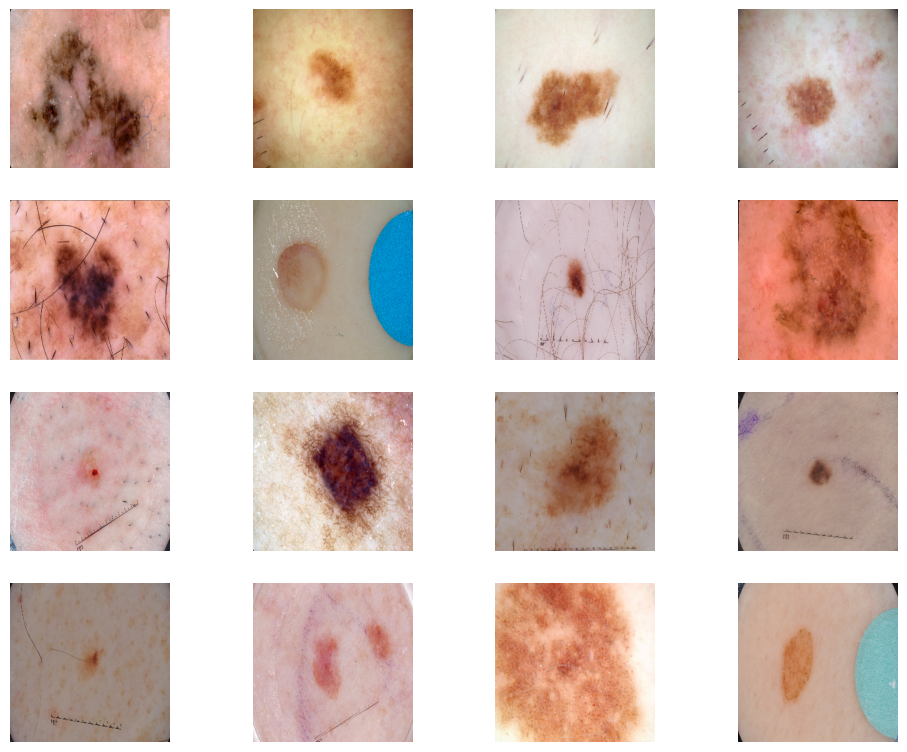

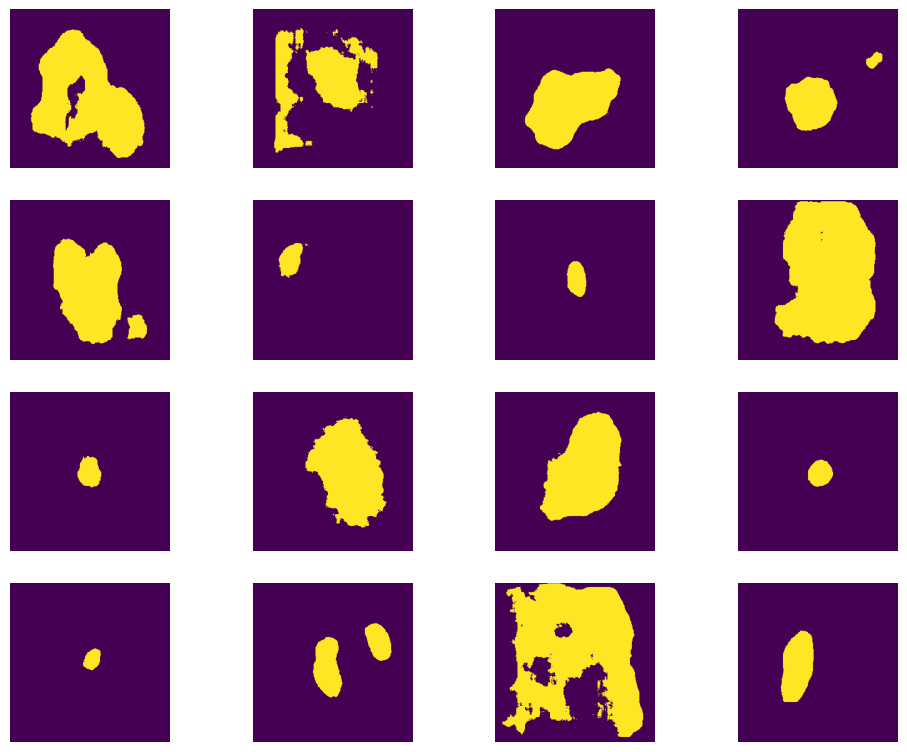

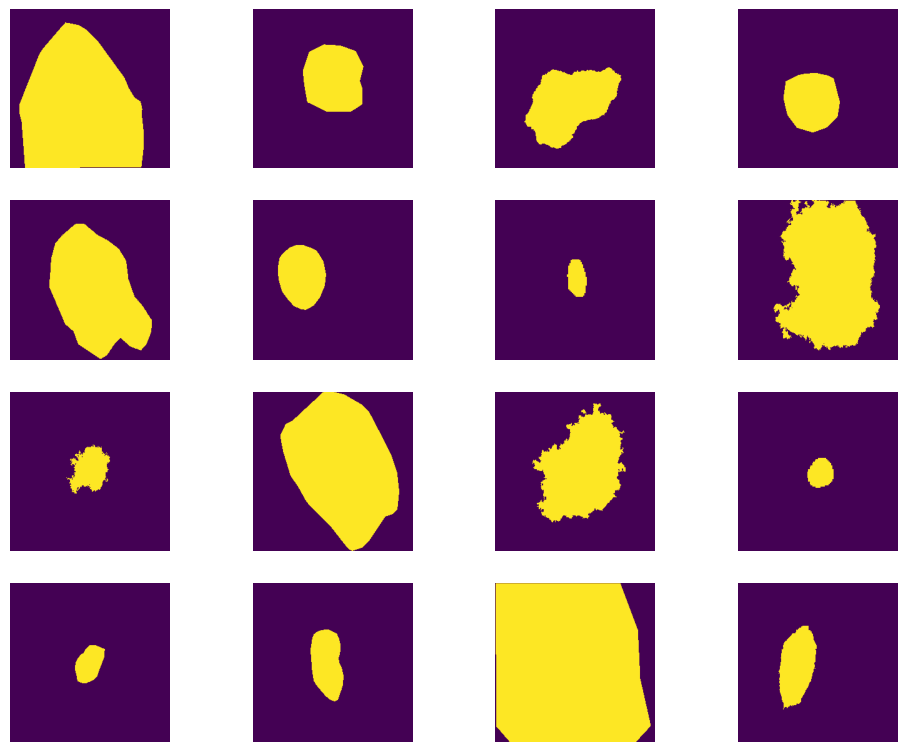

In [116]:
visualize_model(model4,test_loader,16)

In [117]:
#Model Building
class Residual(nn.Module):
    def __init__(self, fn,input_channel,output_channel):
        super().__init__()
        self.fn = fn
        if input_channel!=output_channel:
            self.F=nn.Conv2d(input_channel,output_channel,kernel_size=1,bias=False)
        else:
            self.F=nn.Identity()
    def forward(self, x):
        y=self.F(x)
        return nn.functional.relu(self.fn(x) + y)
def conv_block(input_channel,output_channel,residual=False):
    if not residual:
        return nn.Sequential(
            nn.Conv2d(input_channel, output_channel, 3, padding=1),
            nn.BatchNorm2d(output_channel),
            nn.ReLU(),
            nn.Conv2d(output_channel, output_channel, 3, padding=1),
            nn.BatchNorm2d(output_channel),
            nn.ReLU()
        )
    else:
        return Residual(nn.Sequential(
            nn.Conv2d(input_channel, output_channel, 3, padding=1),
            nn.BatchNorm2d(output_channel),
            nn.ReLU(),
            nn.Conv2d(output_channel, output_channel, 3, padding=1),
            nn.BatchNorm2d(output_channel)
        ),input_channel,output_channel)
class Residual_UNET(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512],):
        super(Residual_UNET, self).__init__()
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
       
        for feature in features:
            self.downs.append(conv_block(in_channels, feature,residual=True))
            in_channels = feature

        for feature in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2,))
            self.ups.append(conv_block(feature*2, feature,residual=True))

        self.bottleneck = nn.Conv2d(features[-1], features[-1]*2,3,padding=1)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]
        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx//2]
            if x.shape != skip_connection.shape:
                x = TF.resize(x, size=skip_connection.shape[2:])
            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx+1](concat_skip)
        x=self.final_conv(x)
        return x
model=Residual_UNET(in_channels=3, out_channels=1, features=[64, 128, 256, 512])
model=model.to(device)
optimizer=optim.Adam(model.parameters(),lr=0.0003,weight_decay=1e-4)
loss_fn=nn.BCEWithLogitsLoss()
train_loss=[]
test_loss=[]
train_model(model,train_loader,test_loader,optimizer,loss_fn,train_loss,test_loss,8)

Step 20 : Intermediate Loss = 0.46
Step 40 : Intermediate Loss = 0.41
Step 60 : Intermediate Loss = 0.38
Step 80 : Intermediate Loss = 0.36
Step 100 : Intermediate Loss = 0.34
Step 120 : Intermediate Loss = 0.33
Epoch 1
Loss : 0.3235
Training Loss
Loss: 0.32
Testing Loss
Loss: 0.31
Loss: 0.3061 | Dice: 0.6410 | IoU: 0.5247
Step 20 : Intermediate Loss = 0.22
Step 40 : Intermediate Loss = 0.24
Step 60 : Intermediate Loss = 0.24
Step 80 : Intermediate Loss = 0.24
Step 100 : Intermediate Loss = 0.24
Step 120 : Intermediate Loss = 0.24
Epoch 2
Loss : 0.2478
Training Loss
Loss: 0.25
Testing Loss
Loss: 0.25
Loss: 0.2546 | Dice: 0.7291 | IoU: 0.6132
Step 20 : Intermediate Loss = 0.26
Step 40 : Intermediate Loss = 0.24
Step 60 : Intermediate Loss = 0.24
Step 80 : Intermediate Loss = 0.23
Step 100 : Intermediate Loss = 0.23
Step 120 : Intermediate Loss = 0.23
Epoch 3
Loss : 0.2277
Training Loss
Loss: 0.23
Testing Loss
Loss: 0.23
Loss: 0.2350 | Dice: 0.7215 | IoU: 0.6185
Step 20 : Intermediate Lo

In [118]:
torch.save(model.state_dict(), "model4.pth")
model5=model

In [130]:
loss_fn=nn.BCEWithLogitsLoss()
stat_model(model5,train_loader,loss_fn)

Loss: 0.1891 | Dice: 0.7709 | IoU: 0.6759


(0.18914543337149986,
 tensor(0.7709, device='cuda:0', dtype=torch.float64),
 0.6759355481824053)

In [131]:
train_img_dir=os.path.join(path,"ISIC2018_Task1-2_Training_Input")
train_mask_dir=os.path.join(path,"ISIC2018_Task1_Training_GroundTruth")
input_img_size=256
batch_size=16
train_transform = A.Compose(
        [
            A.Resize(height=input_img_size, width=input_img_size),
            A.Rotate(limit=35, p=0.6),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.1),
            A.Normalize(
                mean=[0.0, 0.0, 0.0],
                std=[1.0, 1.0, 1.0],
                max_pixel_value=255.0,
            ),
            ToTensorV2(),
        ]
    )

test_transform=A.Compose([
            A.Resize(height=256, width=256),
            A.Normalize(
                mean=[0.0, 0.0, 0.0],
                std=[1.0, 1.0, 1.0],
                max_pixel_value=255.0,
            ),
             ToTensorV2()]
)
dataset=ISIC_Dataset(train_img_dir, train_mask_dir, transform=train_transform)

total_size=len(dataset)
train_size=int(0.8*total_size)
test_size=total_size-train_size

train_dataset,test_dataset=random_split(dataset,[train_size,test_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
model=Residual_UNET(in_channels=3, out_channels=1, features=[64, 128, 256, 512])
model=model.to(device)
optimizer=optim.Adam(model.parameters(),lr=0.0003,weight_decay=1e-4)
loss_fn=nn.BCEWithLogitsLoss()
train_loss=[]
test_loss=[]
train_model(model,train_loader,test_loader,optimizer,loss_fn,train_loss,test_loss,8)

Step 20 : Intermediate Loss = 0.46
Step 40 : Intermediate Loss = 0.39
Step 60 : Intermediate Loss = 0.35
Step 80 : Intermediate Loss = 0.34
Step 100 : Intermediate Loss = 0.31
Step 120 : Intermediate Loss = 0.31
Epoch 1
Loss : 0.3058
Training Loss
Loss: 0.31
Testing Loss
Loss: 0.29
Loss: 0.2917 | Dice: 0.6555 | IoU: 0.5587
Step 20 : Intermediate Loss = 0.28
Step 40 : Intermediate Loss = 0.25
Step 60 : Intermediate Loss = 0.25
Step 80 : Intermediate Loss = 0.25
Step 100 : Intermediate Loss = 0.25
Step 120 : Intermediate Loss = 0.24
Epoch 2
Loss : 0.2391
Training Loss
Loss: 0.24
Testing Loss
Loss: 0.25
Loss: 0.2533 | Dice: 0.7032 | IoU: 0.6089
Step 20 : Intermediate Loss = 0.21
Step 40 : Intermediate Loss = 0.22
Step 60 : Intermediate Loss = 0.21
Step 80 : Intermediate Loss = 0.21
Step 100 : Intermediate Loss = 0.22
Step 120 : Intermediate Loss = 0.21
Epoch 3
Loss : 0.2139
Training Loss
Loss: 0.21
Testing Loss
Loss: 0.20
Loss: 0.2018 | Dice: 0.7748 | IoU: 0.6738
Step 20 : Intermediate Lo